In [14]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [15]:
# Task 1. Data Loading and Inspection
df = pd.read_csv('../data/q1_heart_disease.csv')

print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:\n")
df.head()

Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 Rows:



,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


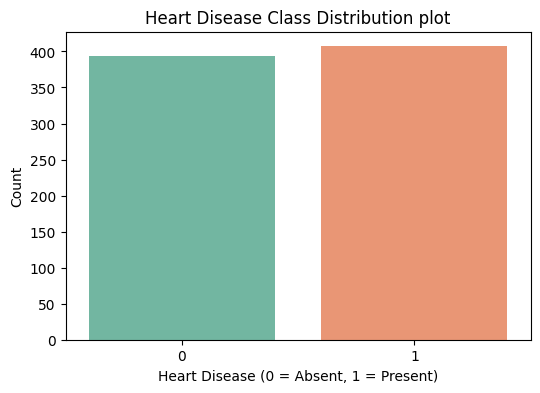

In [16]:
# Task 2. Exploratory Data Analysis

# 1. Target Class Distribution
plt.figure(figsize=(6,4))
sns.countplot( data=df, x='heart_disease', hue='heart_disease', palette='Set2', legend=False)
plt.title("Heart Disease Class Distribution plot")
plt.xlabel("Heart Disease (0 = Absent, 1 = Present)")
plt.ylabel("Count")
plt.show()

### Interpretation: Heart Disease Class Distribution plot
This plot shows how the target classes are distributed between patients with and without heart disease. The classes appear reasonably balanced, which is helpful for classification models because it reduces bias toward one class.

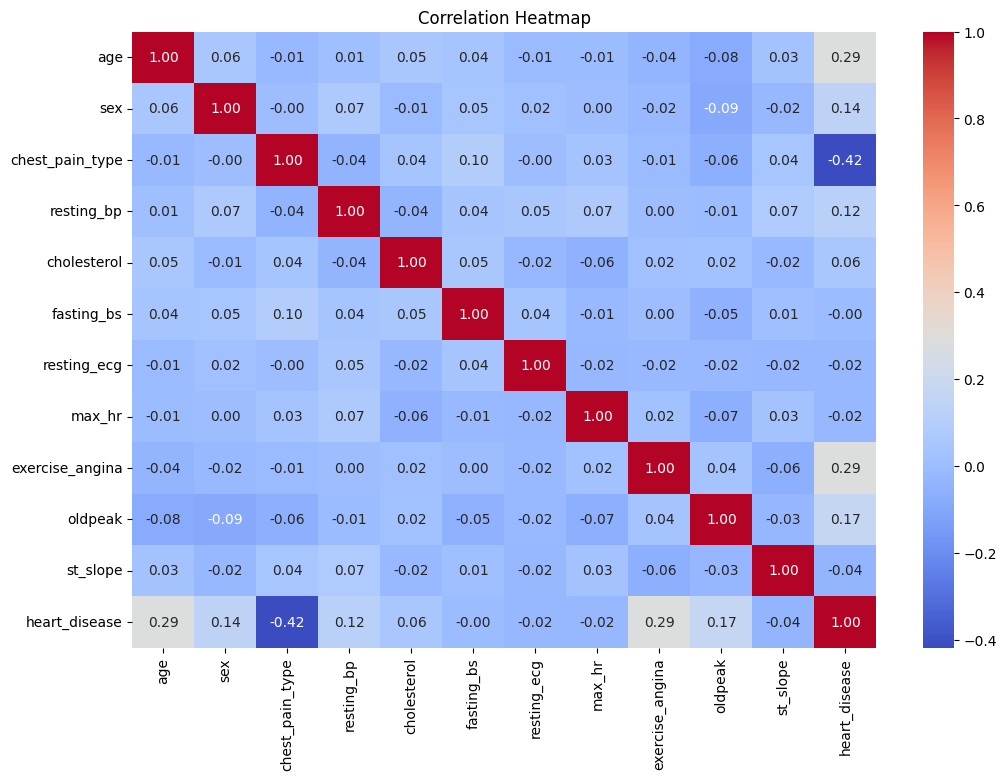

In [17]:
# 2. Correlation Heatmap

# Because correlation works on numeric values, creating a temporary encoded copy for EDA only
eda_df = df.copy()

for col in ['chest_pain_type', 'resting_ecg', 'st_slope']:
    eda_df[col] = eda_df[col].astype('category').cat.codes

plt.figure(figsize=(12,8))
sns.heatmap(eda_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Interpretation: Correlation Heatmap
The heatmap helps identify which variables have stronger relationships with the target. In this dataset, `exercise_angina` and `age` show a positive relationship with `heart_disease`, while `chest_pain_type` appears to have a stronger negative relationship after categorical coding. Highly correlated predictors can be useful signals for model learning.

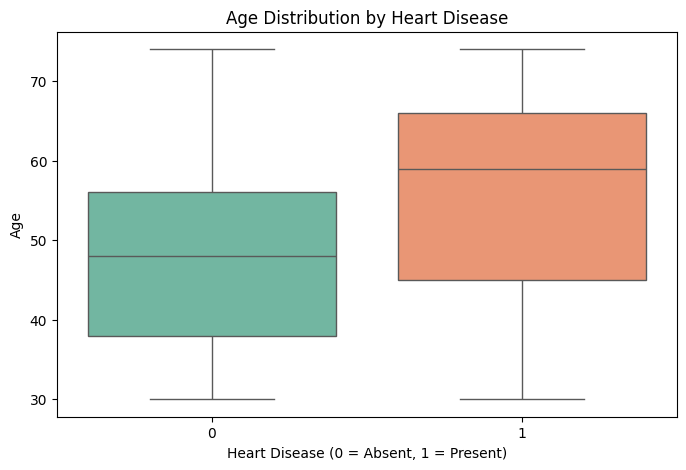

In [18]:
# 3. Age Distribution by Target
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='heart_disease', y='age', hue='heart_disease', palette='Set2', legend=False)
plt.title("Age Distribution by Heart Disease")
plt.xlabel("Heart Disease (0 = Absent, 1 = Present)")
plt.ylabel("Age")
plt.show()

### Interpretation: Age Distribution by Heart Disease
Patients with heart disease tend to be older on average than those without heart disease. This suggests that age may be an important predictive feature, although it should be used alongside other clinical variables rather than in isolation.

In [19]:
# Task 3. Data Preprocessing

# Separate target
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

# Handle missing values
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

Categorical Columns: ['chest_pain_type', 'resting_ecg', 'st_slope']
Numerical Columns: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']


### Missing Value Strategy:
I used median imputation for numerical columns because `resting_bp` and `cholesterol` contain missing values, and median is robust to outliers that are common in medical measurements.

I used most-frequent imputation(mode) for categorical features to preserve valid category values.

I did not drop rows because only a small number of values are missing, and removing rows would unnecessarily reduce the dataset size.

In [20]:
# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Scaling numerical features
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (640, 15)
Test Shape: (160, 15)


In [21]:
# Task 4. Model Training
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)

print("All models trained successfully")

All models trained successfully


In [22]:
# Task 5. Model Evaluation

for name, model in models.items():
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("-"*50)
    print(name)
    print("-"*50)

    print("Confusion Matrix:")
    print(cm)

    print(f'\nPrecision: {precision}')
    print(f'Recall:    {recall}')
    print(f'F1:        {f1}\n\n')

--------------------------------------------------
Decision Tree
--------------------------------------------------
Confusion Matrix:
[[57 22]
 [25 56]]

Precision: 0.717948717948718
Recall:    0.691358024691358
F1:        0.7044025157232704


--------------------------------------------------
Random Forest
--------------------------------------------------
Confusion Matrix:
[[61 18]
 [15 66]]

Precision: 0.7857142857142857
Recall:    0.8148148148148148
F1:        0.8


--------------------------------------------------
Gradient Boosting
--------------------------------------------------
Confusion Matrix:
[[61 18]
 [19 62]]

Precision: 0.775
Recall:    0.7654320987654321
F1:        0.7701863354037267




### Best Model Selection
The Random Forest model performed best overall because it achieved the highest F1-score on the test set. Its precision was about 0.7857, recall was about 0.8148, and F1-score was about 0.8, which is higher than both Gradient Boosting and Decision Tree. I selected F1-score as the main comparison metric because it balances both precision and recall, making it more informative than accuracy alone for a medical classification problem.

In [23]:
# Task 6. Hyperparameter Tuning

# tuning random forest model
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [24]:
# Evaluate Tuned Model

best_rf = grid.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("Tuned Random Forest Performance")
print("Confusion Matrix:\n", cm_tuned)
print("\nPrecision:",precision_tuned)
print("Recall:   " , recall_tuned)
print("F1-score: ", f1_tuned,)

Tuned Random Forest Performance
Confusion Matrix:
 [[57 22]
 [15 66]]

Precision: 0.75
Recall:    0.8148148148148148
F1-score:  0.7810650887573964


### Hyperparameter Tuning Result
I tuned the Random Forest model using GridSearchCV. Although the tuned model achieved the selected best cross-validation parameters, its performance on the test set did not improve over the untuned baseline. The untuned Random Forest had a higher F1-score (0.80) than the tuned model (0.7811), while recall remained the same at 0.8148. This suggests that the baseline Random Forest generalized slightly better to the unseen test data for this dataset.